# Football Team Performance Analysis Project
This notebook performs a comprehensive analysis of football match data using PySpark, focusing on historical performance across different divisions.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark as spk
from pyspark.sql import SparkSession
print('done!')

done!


## 1. Environment Configuration and Data Loading
In this section, we define the file paths, initialize the Spark session, and load the raw dataset from Google Drive.

In [2]:
# paths
project_path = '/content/drive/MyDrive/simplon_projects/PySpark Project'
dataset_path = os.path.join(project_path, 'football_team_data.csv')

In [3]:
spark = SparkSession.builder.appName('Football_team_Analysis').getOrCreate()
print(f'New Spark Session Has been created with Name : {spark.sparkContext.appName}')

New Spark Session Has been created with Name : Football_team_Analysis


In [4]:
# Now that the path is fixed, this should load correctly
df = spark.read.csv(dataset_path, header=True, inferSchema=True)
df.show()

+--------+---+------+----------+------------------+--------------+----+----+---+
|Match_ID|Div|Season|      Date|          HomeTeam|      AwayTeam|FTHG|FTAG|FTR|
+--------+---+------+----------+------------------+--------------+----+----+---+
|       1| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|   2|   1|  H|
|       2| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|   0|   1|  A|
|       3| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|   1|   1|  D|
|       4| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|   2|   1|  H|
|       5| D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|   1|   3|  A|
|       6| D2|  2009|2010-04-03|      Union Berlin|     Karlsruhe|   1|   1|  D|
|       7| D2|  2009|2009-08-14|         Paderborn|     Karlsruhe|   2|   0|  H|
|       8| D2|  2009|2010-03-08|         Bielefeld|     Karlsruhe|   0|   1|  A|
|       9| D2|  2009|2009-09-26|    Kaiserslautern|     Karlsruhe|   2|   0|  H|
|      10| D2|  2009|2009-11

## 2. Exploratory Data Analysis (EDA) and Schema Definition
Here we examine the dataset structure, rename columns for clarity, and analyze the distribution of matches across leagues and teams.

### Dataset Column Definitions

| Column | Description |
| :--- | :--- |
| **Match_ID** | Unique identifier for each match record. |
| **Div** | League Division (e.g., **E0** = English Premier League, **D1** = German Bundesliga 1, **D2** = German Bundesliga 2). |
| **Season** | The year the football season started. |
| **Date** | The specific date the match was played. |
| **HomeTeam** | The name of the team playing at their own stadium. |
| **AwayTeam** | The name of the visiting team. |
| **FTHG** | Full-Time Home Goals (Goals scored by the home team). |
| **FTAG** | Full-Time Away Goals (Goals scored by the away team). |
| **FTR** | Full-Time Result (**H** = Home Win, **D** = Draw, **A** = Away Win). |

In [5]:
df = df.withColumnRenamed("Div", "Division")
df.columns

['Match_ID',
 'Division',
 'Season',
 'Date',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR']

In [6]:
print(f"Total Rows of the DataFrame is : {df.count()}")
print(f"Total Columns of the DataFrame is : , {len(df.columns)}")

Total Rows of the DataFrame is : 24625
Total Columns of the DataFrame is : , 9


In [7]:
df.select('Division').distinct().show()

+--------+
|Division|
+--------+
|      D1|
|      E0|
|      D2|
+--------+



In [8]:
df.groupBy('Division').count().show()

+--------+-----+
|Division|count|
+--------+-----+
|      D1| 7650|
|      E0| 9284|
|      D2| 7691|
+--------+-----+



In [9]:
# list of df columns excluding "Match_ID" :
columns = ['FTR', 'AwayTeam', 'HomeTeam', 'Division']
for col in columns :
  print(f"Counts for {col}:")
  df.groupBy(col).count().show()

Counts for FTR:
+---+-----+
|FTR|count|
+---+-----+
|  D| 6393|
|  A| 6453|
|  H|11779|
+---+-----+

Counts for AwayTeam:
+--------------+-----+
|      AwayTeam|count|
+--------------+-----+
|         Mainz|  427|
|Kaiserslautern|  393|
|     Tottenham|  460|
|    Schalke 04|  425|
|      Nurnberg|  408|
|        Bolton|  247|
|    M'Gladbach|   17|
|    Reutlingen|   51|
|           Ulm|   51|
|  Union Berlin|  204|
|Sheffield Weds|  137|
|    Sunderland|  304|
| Nott'm Forest|   78|
| Frankfurt FSV|  136|
|      Bradford|   38|
|   Schweinfurt|   17|
|          Hull|   95|
|        Siegen|   17|
|      Coventry|  156|
|       Swindon|   21|
+--------------+-----+
only showing top 20 rows
Counts for HomeTeam:
+--------------+-----+
|      HomeTeam|count|
+--------------+-----+
|         Mainz|  425|
|Kaiserslautern|  425|
|     Tottenham|  460|
|    Schalke 04|  425|
|      Nurnberg|  407|
|        Bolton|  247|
|    M'Gladbach|   17|
|    Reutlingen|   51|
|           Ulm|   51|
|  U

## 3. Feature Engineering and Data Filtering
### 3.1 Creating Win/Loss/Tie Indicators
We transform the categorical match results into numerical indicator columns and filter the data for the Bundesliga (D1) between 2000 and 2015.

In [10]:
from pyspark.sql.functions import col, when
df = df.withColumn("HomeTeamWin",
                   when(col("FTR") == "H", 1).otherwise(0)
                   ) \
       .withColumn('AwayTeamWin',
                     when(col('FTR') == "A", 1).otherwise(0)
                     ) \
       .withColumn('GameTie',
                     when(col('FTR') == "D", 1).otherwise(0)
                     )

df.show()

+--------+--------+------+----------+------------------+--------------+----+----+---+-----------+-----------+-------+
|Match_ID|Division|Season|      Date|          HomeTeam|      AwayTeam|FTHG|FTAG|FTR|HomeTeamWin|AwayTeamWin|GameTie|
+--------+--------+------+----------+------------------+--------------+----+----+---+-----------+-----------+-------+
|       1|      D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|   2|   1|  H|          1|          0|      0|
|       2|      D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|   0|   1|  A|          0|          1|      0|
|       3|      D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|   1|   1|  D|          0|          0|      1|
|       4|      D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|   2|   1|  H|          1|          0|      0|
|       5|      D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|   1|   3|  A|          0|          1|      0|
|       6|      D2|  2009|2010-04-03|      Union Berlin|

In [11]:
division_condition = col('Division') == 'D1'
Season_condition = (col('Season') >= 2000) & (col('Season') <= 2015)
df_filtered = df.filter(division_condition & Season_condition)
df_filtered.show()

+--------+--------+------+----------+-------------+----------+----+----+---+-----------+-----------+-------+
|Match_ID|Division|Season|      Date|     HomeTeam|  AwayTeam|FTHG|FTAG|FTR|HomeTeamWin|AwayTeamWin|GameTie|
+--------+--------+------+----------+-------------+----------+----+----+---+-----------+-----------+-------+
|      21|      D1|  2009|2010-02-06|       Bochum|Leverkusen|   1|   1|  D|          0|          0|      1|
|      22|      D1|  2009|2009-11-22|Bayern Munich|Leverkusen|   1|   1|  D|          0|          0|      1|
|      23|      D1|  2009|2010-05-08|   M'gladbach|Leverkusen|   1|   1|  D|          0|          0|      1|
|      24|      D1|  2009|2009-08-08|        Mainz|Leverkusen|   2|   2|  D|          0|          0|      1|
|      25|      D1|  2009|2009-10-17|      Hamburg|Leverkusen|   0|   0|  D|          0|          0|      1|
|      26|      D1|  2009|2010-04-17|    Stuttgart|Leverkusen|   2|   1|  H|          1|          0|      0|
|      27|      D1|

## 4. Statistical Aggregation
### 4.1 Home and Away Performance
This section calculates comprehensive statistics (wins, losses, goals) separately for teams playing at home versus away using a dynamic loop.

Home Statistics

In [12]:
from pyspark.sql.functions import sum, count
HomeOrAway = {'Home':'Away', 'Away' : 'Home'}
for Name in HomeOrAway.keys() :
  opp = HomeOrAway[Name]

  globals()[f'df_{Name}_matches'] = df_filtered.groupBy(f'{Name}Team', 'Season')\
                              .agg(
                                      sum(f'{Name}TeamWin').alias(f'{Name}Wins'),
                                      sum(f'{opp}TeamWin').alias(f'{Name}Losses'),
                                      sum('GameTie').alias(f'{Name}Ties'),
                                      sum('FTHG' if Name == 'Home' else 'FTAG')\
                                              .alias(f'{Name}GoalsScored'),
                                      sum('FTAG' if Name == 'Home' else 'FTHG' )\
                                              .alias(f'{Name}GoalsAgainst'),
                                      count(f'{Name}Team').alias(f'{Name}GamesPlayed')
                                    )\
                              .orderBy('Season')\
                              .withColumnRenamed(f'{Name}Team', 'Team')\
                              .withColumn(f'{Name}SeasonScoringResults', when (col(f'{Name}GoalsScored') > col(f'{Name}GoalsAgainst'), 'OutScored').otherwise('OutConceded'))





In [13]:
df_Home_matches.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+
|          Team|Season|HomeWins|HomeLosses|HomeTies|HomeGoalsScored|HomeGoalsAgainst|HomeGamesPlayed|HomeSeasonScoringResults|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+
| Bayern Munich|  2000|      12|         4|       1|             37|              20|             17|               OutScored|
|      Freiburg|  2000|       9|         3|       5|             36|              15|             17|               OutScored|
|       Cottbus|  2000|      10|         6|       1|             27|              20|             17|               OutScored|
|    Schalke 04|  2000|      12|         1|       4|             36|              13|             17|               OutScored|
|     Wolfsburg|  2000|       8|         3|       6|             38|              18|             17|          

In [14]:
df_Away_matches.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+
|          Team|Season|AwayWins|AwayLosses|AwayTies|AwayGoalsScored|AwayGoalsAgainst|AwayGamesPlayed|AwaySeasonScoringResults|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+
| Bayern Munich|  2000|       7|         5|       5|             25|              17|             17|               OutScored|
|      Freiburg|  2000|       6|         6|       5|             18|              22|             17|             OutConceded|
|       Cottbus|  2000|       2|        13|       2|             11|              32|             17|             OutConceded|
|    Schalke 04|  2000|       6|         7|       4|             29|              22|             17|               OutScored|
|     Wolfsburg|  2000|       4|         8|       5|             22|              27|             17|          

### 4.2 Merging Stats and Season Summaries
We join the home and away dataframes to calculate season-long totals and advanced metrics like Win Percentage and Goals Per Game.

In [15]:
df_matches_merged = df_Home_matches.join(df_Away_matches,
                                         on = ['Team', 'Season'],
                                         how = 'outer')\
                                   .orderBy('Season')
df_matches_merged.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+
|          Team|Season|HomeWins|HomeLosses|HomeTies|HomeGoalsScored|HomeGoalsAgainst|HomeGamesPlayed|HomeSeasonScoringResults|AwayWins|AwayLosses|AwayTies|AwayGoalsScored|AwayGoalsAgainst|AwayGamesPlayed|AwaySeasonScoringResults|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+
|      Dortmund|  2000|       9|         4|       4|             34|              20|             17|               OutScored|       7|         4|       6|             28|              22|             17|               OutScored|
|        Bochum|  2000|       5|         8|       4|             20|            

In [16]:
df_matches = df_matches_merged.withColumn('TotalGoalsScored', col('HomeGoalsScored') + col('AwayGoalsScored'))\
                              .withColumn('TotalGoalsAgainst', col('HomeGoalsAgainst') + col('AwayGoalsAgainst'))\
                              .withColumn('TotalGamesPlayed', col('HomeGamesPlayed') + col('AwayGamesPlayed'))\
                              .withColumn('TotalWins', col('HomeWins') + col('AwayWins'))\
                              .withColumn('TotalLosses', col('HomeLosses') + col('AwayLosses'))\
                              .withColumn('TotalTies', col('HomeTies') + col('AwayTies'))\
                              .orderBy('Season')
df_matches.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+----------------+-----------------+----------------+---------+-----------+---------+
|          Team|Season|HomeWins|HomeLosses|HomeTies|HomeGoalsScored|HomeGoalsAgainst|HomeGamesPlayed|HomeSeasonScoringResults|AwayWins|AwayLosses|AwayTies|AwayGoalsScored|AwayGoalsAgainst|AwayGamesPlayed|AwaySeasonScoringResults|TotalGoalsScored|TotalGoalsAgainst|TotalGamesPlayed|TotalWins|TotalLosses|TotalTies|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+----------------+-----------------+----------------+---------+-----------+---------+
|      Dortmund|  2000|       9|         4|       4|      

In [17]:
from pyspark.sql.functions import round
df_matches = df_matches.withColumn("GoalDifferentials", col("TotalGoalsScored") - col("TotalGoalsAgainst"))\
                       .withColumn("WinPercentage", round(
                                  (col("TotalWins") / col("TotalGamesPlayed"))*100, 2))\
                       .withColumn('GoalsPerGame', round(col("TotalGoalsScored") / col("TotalGamesPlayed"), 2))\
                       .withColumn('GoalsAgainstPerGame', round(col('TotalGoalsAgainst') / col('TotalGamesPlayed'),2))\
                       .orderBy('Season')
df_matches.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+----------------+-----------------+----------------+---------+-----------+---------+-----------------+-------------+------------+-------------------+
|          Team|Season|HomeWins|HomeLosses|HomeTies|HomeGoalsScored|HomeGoalsAgainst|HomeGamesPlayed|HomeSeasonScoringResults|AwayWins|AwayLosses|AwayTies|AwayGoalsScored|AwayGoalsAgainst|AwayGamesPlayed|AwaySeasonScoringResults|TotalGoalsScored|TotalGoalsAgainst|TotalGamesPlayed|TotalWins|TotalLosses|TotalTies|GoalDifferentials|WinPercentage|GoalsPerGame|GoalsAgainstPerGame|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+-------------

## 5. Competitive Ranking Logic
### 5.1 Ranking Teams by Season
Using Spark Window functions, we rank teams within each season based on Win Percentage and Goal Differential to identify the 'Champions'.

In [18]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, desc

window_spec = Window.partitionBy('Season').orderBy(
                                                    desc('WinPercentage'),
                                                    desc('GoalDifferentials')
                                                  )

df_ranked = df_matches.withColumn('TeamPosition', rank().over(window_spec))
df_ranked.show()

+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------------------+----------------+-----------------+----------------+---------+-----------+---------+-----------------+-------------+------------+-------------------+------------+
|          Team|Season|HomeWins|HomeLosses|HomeTies|HomeGoalsScored|HomeGoalsAgainst|HomeGamesPlayed|HomeSeasonScoringResults|AwayWins|AwayLosses|AwayTies|AwayGoalsScored|AwayGoalsAgainst|AwayGamesPlayed|AwaySeasonScoringResults|TotalGoalsScored|TotalGoalsAgainst|TotalGamesPlayed|TotalWins|TotalLosses|TotalTies|GoalDifferentials|WinPercentage|GoalsPerGame|GoalsAgainstPerGame|TeamPosition|
+--------------+------+--------+----------+--------+---------------+----------------+---------------+------------------------+--------+----------+--------+---------------+----------------+---------------+------------

## 6. Data Persistence
Saving the processed results as partitioned Parquet files for optimized future access.

In [19]:
df_ranked.write\
         .mode('overwrite')\
         .partitionBy('Season')\
         .parquet(os.path.join(project_path, 'football_statistics_partitioned'))

df_champions = df_ranked.filter(col('TeamPosition') == 1)\
                        .orderBy('Season')
df_champions.write\
            .mode('overwrite')\
            .parquet(os.path.join(project_path, 'football_top_teams'))

## 7. Results Visualization
### 7.1 Champion Trends
Converting the top-performing teams to Pandas to visualize winning trends and scoring consistency over the years.

In [20]:
df_pd_champions = df_champions.orderBy('Season').toPandas()
df_pd_champions.head()

,Team,Season,HomeWins,HomeLosses,HomeTies,HomeGoalsScored,HomeGoalsAgainst,HomeGamesPlayed,HomeSeasonScoringResults,AwayWins,...,TotalGoalsAgainst,TotalGamesPlayed,TotalWins,TotalLosses,TotalTies,GoalDifferentials,WinPercentage,GoalsPerGame,GoalsAgainstPerGame,TeamPosition
0,Bayern Munich,2000,12,4,1,37,20,17,OutScored,7,...,37,34,19,9,6,25,55.88,1.82,1.09,1
1,Leverkusen,2001,14,2,1,46,13,17,OutScored,7,...,38,34,21,7,6,39,61.76,2.26,1.12,1
2,Bayern Munich,2002,13,1,3,37,12,17,OutScored,10,...,25,34,23,5,6,45,67.65,2.06,0.74,1
3,Werder Bremen,2003,11,2,4,42,21,17,OutScored,11,...,38,34,22,4,8,41,64.71,2.32,1.12,1
4,Bayern Munich,2004,14,1,2,44,14,17,OutScored,10,...,33,34,24,5,5,42,70.59,2.21,0.97,1


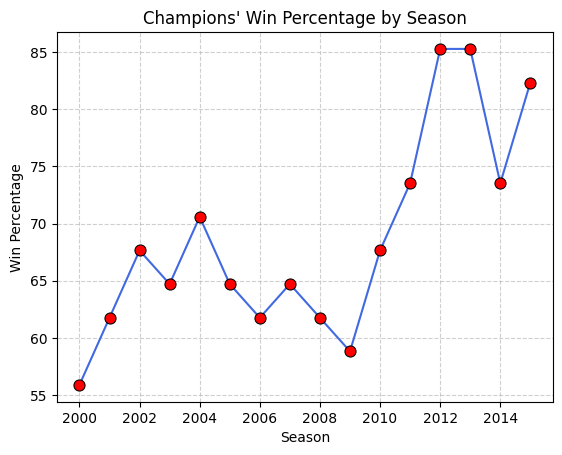

In [21]:
sns.lineplot(
    data = df_pd_champions,
    x= 'Season',
    y= 'WinPercentage',
    marker= 'o',
    color = 'royalblue',
    markerfacecolor = 'red',
    markeredgecolor = 'black',
    markersize = 8,
    alpha = 1
)
plt.xlabel('Season')
plt.ylabel('Win Percentage')
plt.title("Champions' Win Percentage by Season")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

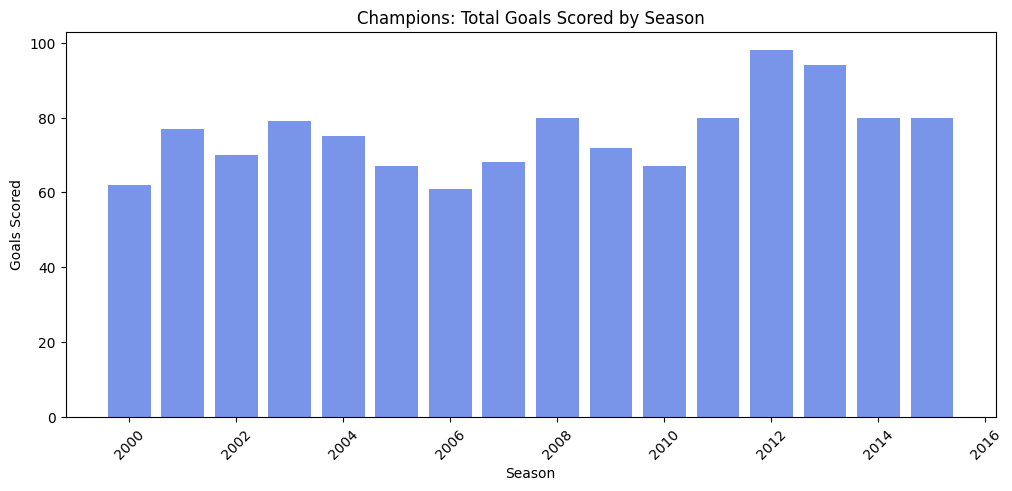

In [22]:
plt.figure(figsize=(12, 5))
plt.bar(df_pd_champions["Season"],
        df_pd_champions["TotalGoalsScored"],
        color='royalblue',
        alpha=0.7)

plt.title("Champions: Total Goals Scored by Season")
plt.xlabel("Season")
plt.ylabel("Goals Scored")
plt.xticks(rotation=45)
plt.show()

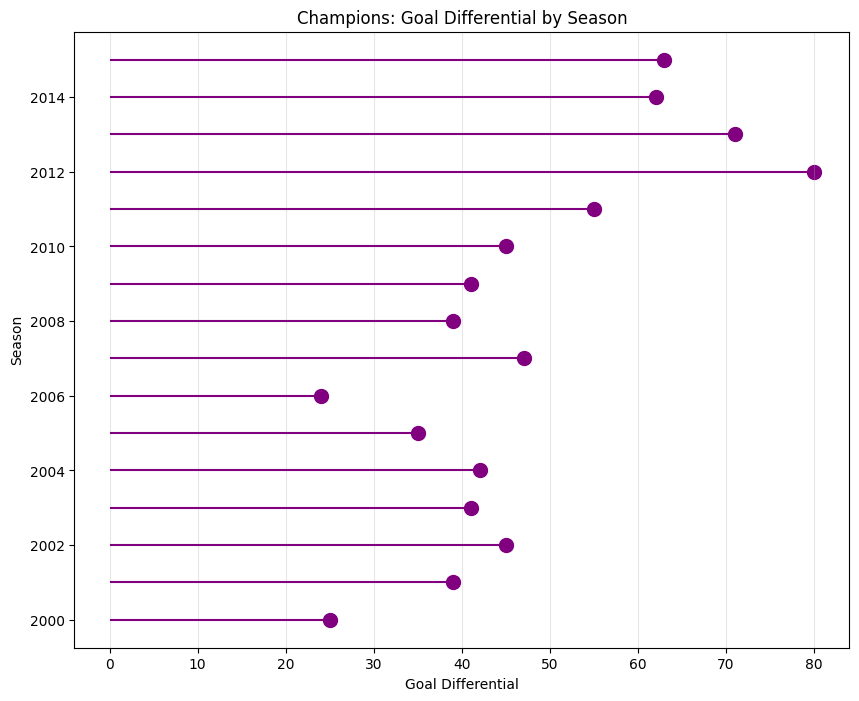

In [23]:
plt.figure(figsize=(10, 8))


df_sorted = df_pd_champions.sort_values("GoalDifferentials")

plt.hlines(
    y=df_sorted["Season"],
    xmin=0,
    xmax=df_sorted["GoalDifferentials"],
    color='purple',
    alpha=1
)

plt.scatter(
    df_sorted["GoalDifferentials"],
    df_sorted["Season"],
    color='purple',
    s=100
)

plt.title("Champions: Goal Differential by Season")
plt.xlabel("Goal Differential")
plt.ylabel("Season")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [26]:
print('DataFrame Schema:')
df_ranked.printSchema()
print(f'Number of rows: {df_ranked.count()}')

DataFrame Schema:
root
 |-- Team: string (nullable = true)
 |-- Season: integer (nullable = true)
 |-- HomeWins: long (nullable = true)
 |-- HomeLosses: long (nullable = true)
 |-- HomeTies: long (nullable = true)
 |-- HomeGoalsScored: long (nullable = true)
 |-- HomeGoalsAgainst: long (nullable = true)
 |-- HomeGamesPlayed: long (nullable = true)
 |-- HomeSeasonScoringResults: string (nullable = true)
 |-- AwayWins: long (nullable = true)
 |-- AwayLosses: long (nullable = true)
 |-- AwayTies: long (nullable = true)
 |-- AwayGoalsScored: long (nullable = true)
 |-- AwayGoalsAgainst: long (nullable = true)
 |-- AwayGamesPlayed: long (nullable = true)
 |-- AwaySeasonScoringResults: string (nullable = true)
 |-- TotalGoalsScored: long (nullable = true)
 |-- TotalGoalsAgainst: long (nullable = true)
 |-- TotalGamesPlayed: long (nullable = true)
 |-- TotalWins: long (nullable = true)
 |-- TotalLosses: long (nullable = true)
 |-- TotalTies: long (nullable = true)
 |-- GoalDifferentials: long

In [24]:
readme_content = """# Week 18 - Data Engineering with Apache Spark - PySpark

## Bundesliga Football Analysis Pipeline

### Pipeline Stages
1. **Loading & Prep** — CSV → PySpark DataFrame
2. **Indicators** — HomeTeamWin, AwayTeamWin, GameTie
3. **Filtering** — Bundesliga D1, Seasons 2000–2015
4. **Aggregations** — Home & Away stats separately
5. **Join** — Merge home + away per team/season
6. **Metrics** — GoalsScored, GoalsAgainst, Win%, GoalDifferential, etc.
7. **Ranking** — Window function by season (Win% → Goal Diff)
8. **Export** — Partitioned Parquet + Champions Parquet
9. **Visualization** — 3 charts of champion performance

### Outputs
| File | Description |
|------|-------------|
| `football_stats_partitioned/` | All teams, partitioned by Season (Parquet) |
| `football_top_teams/` | Season champions only (Parquet) |
| `visuals/` | 3 PNG charts |
| `*.ipynb` | Colab notebook with full pipeline |

### Tech Stack
- PySpark
- Google Colab
- Matplotlib / Seaborn
- Parquet (partitioned storage)
"""

with open(os.path.join(project_path, "README.md"), "w") as f:
    f.write(readme_content)

print("README created")

✅ README created


project ends